In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import statsmodels
import yfinance as yf

print("Setup works!")

Setup works!


In [20]:
tickers = ["SPY", "AAPL"]
start_date = "2022-01-01"
end_date = "2025-12-31"

In [21]:
import yfinance as yf

spy = yf.download(
    "SPY",
    start="2022-01-01",
    end="2026-01-01",
    auto_adjust=False
)

aapl = yf.download(
    "AAPL",
    start="2022-01-01",
    end="2026-01-01",
    auto_adjust=False
)

[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


In [22]:
spy.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY,SPY
Date,,,,,,
2022-01-03,449.486420,477.709991,477.850006,473.850006,476.299988,72668200
2022-01-04,449.335846,477.549988,479.980011,475.579987,479.220001,71178700
2022-01-05,440.707672,468.380005,477.980011,468.279999,477.160004,104538900
2022-01-06,440.293640,467.940002,470.820007,465.429993,467.890015,86858900
2022-01-07,438.553009,466.089996,469.200012,464.649994,467.950012,85111600


In [23]:
aapl.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2022-01-03,177.786392,182.009995,182.880005,177.710007,177.830002,104487900
2022-01-04,175.529999,179.699997,182.940002,179.119995,182.630005,99310400
2022-01-05,170.860901,174.919998,180.169998,174.639999,179.610001,94537600
2022-01-06,168.008652,172.000000,175.300003,171.639999,172.699997,96904000
2022-01-07,168.174759,172.169998,174.139999,171.029999,172.889999,86709100


In [24]:
spy_price = spy["Adj Close"].dropna()
spy_price.head()

Ticker,SPY
Date,
2022-01-03,449.486420
2022-01-04,449.335846
2022-01-05,440.707672
2022-01-06,440.293640
2022-01-07,438.553009


In [25]:
spy_returns = np.log(spy_price) - np.log(spy_price.shift(1))
spy_returns = spy_returns.dropna()

NameError: name 'q001' is not defined

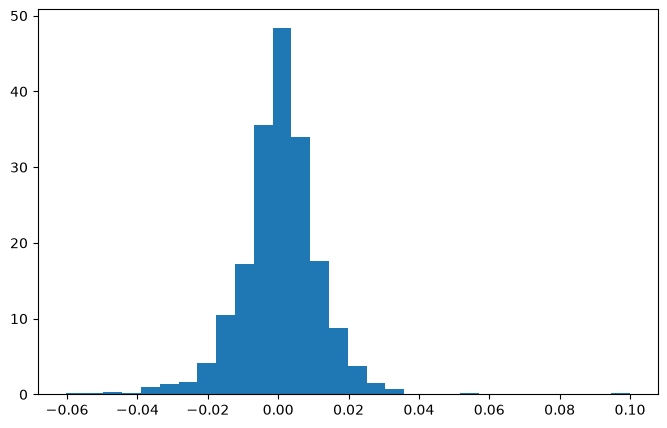

In [26]:
for B in [30, 60, 120]:
    counts, bin_edges = np.histogram(
        spy_returns,
        bins=B,
        density=True
    )

    bin_widths = np.diff(bin_edges)

    plt.figure(figsize=(8, 5))
    plt.bar(
        bin_edges[:-1],
        counts,
        width=bin_widths,
        align="edge"
    )

    plt.xlim(q001, q999)
    plt.xlabel("Daily log-return")
    plt.ylabel("Density")
    plt.title(f"SPY Daily Log-Returns — {B} bins")
    plt.show()

    area = np.sum(counts * bin_widths)
    print(f"B = {B}, total area = {area:.6f}")

In [27]:
aapl_price = aapl["Adj Close"].dropna()

In [28]:
aapl_returns = np.log(aapl_price) - np.log(aapl_price.shift(1))
aapl_returns = aapl_returns.dropna()

NameError: name 'q001' is not defined

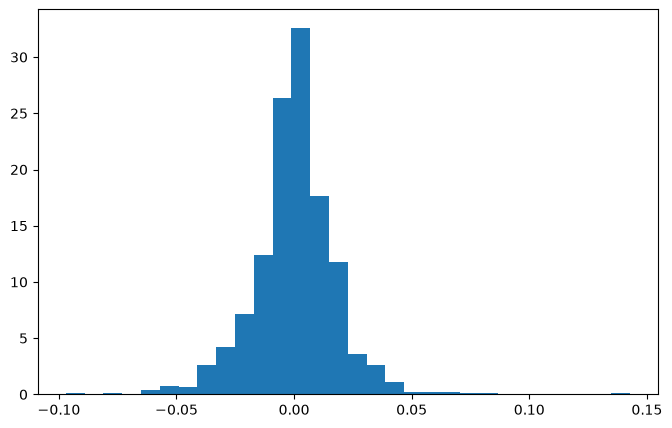

In [29]:
for B in [30, 60, 120]:
    counts, bin_edges = np.histogram(
        aapl_returns,
        bins=B,
        density=True
    )

    bin_widths = np.diff(bin_edges)

    plt.figure(figsize=(8, 5))
    plt.bar(
        bin_edges[:-1],
        counts,
        width=bin_widths,
        align="edge"
    )

    plt.xlim(q001, q999)
    plt.xlabel("Daily log-return")
    plt.ylabel("Density")
    plt.title(f"AAPL Daily Log-Returns — {B} bins")
    plt.show()

    area = np.sum(counts * bin_widths)
    print(f"B = {B}, total area = {area:.6f}")

In [30]:
#problem 1b

In [31]:
spy.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY,SPY
Date,,,,,,
2022-01-03,449.486420,477.709991,477.850006,473.850006,476.299988,72668200
2022-01-04,449.335846,477.549988,479.980011,475.579987,479.220001,71178700
2022-01-05,440.707672,468.380005,477.980011,468.279999,477.160004,104538900
2022-01-06,440.293640,467.940002,470.820007,465.429993,467.890015,86858900
2022-01-07,438.553009,466.089996,469.200012,464.649994,467.950012,85111600


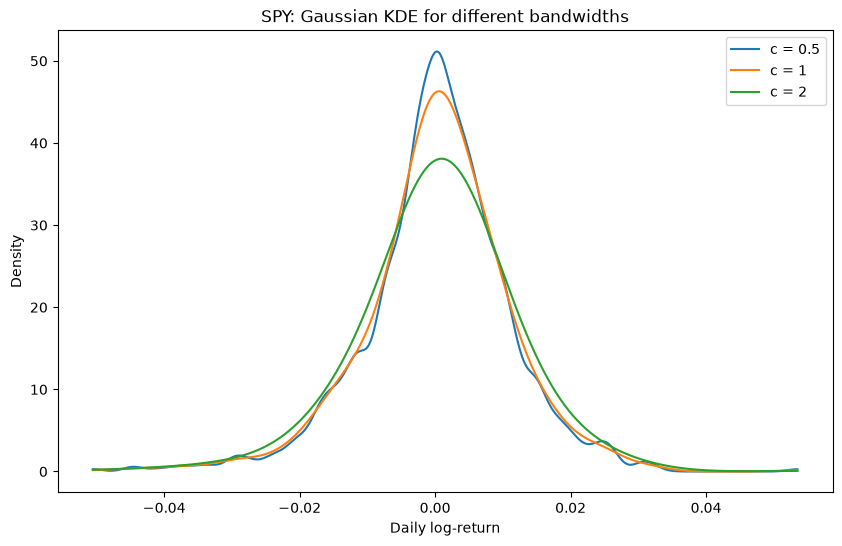

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# Convert returns from a one-column DataFrame to a 1D array
data = spy_returns.to_numpy().ravel()

# Number of observations
n = len(data)

# Scott's bandwidth factor
h_scott = n ** (-1 / 5)

# Standard deviation of the data
s = np.std(data, ddof=1)

# Reference bandwidth
h = h_scott * s

# x-values over which we evaluate the KDE
x = np.linspace(
    np.quantile(data, 0.001),
    np.quantile(data, 0.999),
    1000
)

# Gaussian KDE function
def gaussian_kde_manual(x, data, bandwidth):
    n = len(data)

    u = (x[:, None] - data[None, :]) / bandwidth

    kernel_values = (
        1 / np.sqrt(2 * np.pi)
        * np.exp(-0.5 * u**2)
    )

    return np.sum(kernel_values, axis=1) / (n * bandwidth)


# Plot the three bandwidths
plt.figure(figsize=(10, 6))

for c in [0.5, 1, 2]:
    bandwidth = c * h

    density = gaussian_kde_manual(
        x,
        data,
        bandwidth
    )

    plt.plot(
        x,
        density,
        label=f"c = {c}"
    )

plt.xlabel("Daily log-return")
plt.ylabel("Density")
plt.title("SPY: Gaussian KDE for different bandwidths")
plt.legend()
plt.show()

In [33]:
mu_spy = np.mean(data)

sigma_spy = np.sqrt(
    np.mean((data - mu_spy)**2)
)

print("SPY Gaussian MLE:")
print("mu =", mu_spy)
print("sigma =", sigma_spy)

SPY Gaussian MLE:
mu = 0.00041068513367792007
sigma = 0.011320353616618728


In [34]:
aapl_price = aapl["Adj Close"].dropna()

In [35]:
aapl_returns = np.log(
    aapl_price / aapl_price.shift(1)
).dropna()

In [36]:
aapl_data = aapl_returns.to_numpy().ravel()

mu_aapl = np.mean(aapl_data)

sigma_aapl = np.sqrt(
    np.mean((aapl_data - mu_aapl)**2)
)

print("AAPL Gaussian MLE:")
print("mu =", mu_aapl)
print("sigma =", sigma_aapl)

AAPL Gaussian MLE:
mu = 0.000421143864658219
sigma = 0.017885838222231693


In [37]:
from scipy import optimize
print("optimize works")

optimize works


In [38]:
import numpy as np
from scipy import optimize
from scipy.special import gammaln

In [39]:
import numpy as np
from scipy import optimize
from scipy.special import gammaln


# ============================================================
# 1. Prepare the return data
# ============================================================

spy_data = spy_returns.to_numpy().ravel()
aapl_data = aapl_returns.to_numpy().ravel()


# ============================================================
# 2. Gaussian MLE
# ============================================================

def gaussian_mle(data):
    mu = np.mean(data)

    # MLE variance uses 1/n, NOT 1/(n-1)
    sigma = np.sqrt(np.mean((data - mu)**2))

    return mu, sigma


mu_spy, sigma_spy = gaussian_mle(spy_data)
mu_aapl, sigma_aapl = gaussian_mle(aapl_data)


# ============================================================
# 3. Student-t negative log-likelihood
# ============================================================

def student_t_nll(theta, data):
    # theta contains:
    # theta[0] = mu
    # theta[1] = log(s)
    # theta[2] = log(nu)

    mu = theta[0]
    s = np.exp(theta[1])
    nu = np.exp(theta[2])

    z = (data - mu) / s

    log_pdf = (
        gammaln((nu + 1) / 2)
        - gammaln(nu / 2)
        - 0.5 * np.log(nu * np.pi)
        - np.log(s)
        - ((nu + 1) / 2) * np.log1p(z**2 / nu)
    )

    # We minimize negative log-likelihood
    return -np.sum(log_pdf)


# ============================================================
# 4. Student-t MLE
# ============================================================

def student_t_mle(data, sigma_start):
    best_result = None

    # Try several starting values for nu
    for nu_start in [2.5, 3, 5, 10, 20]:
        theta0 = np.array([
            np.mean(data),
            np.log(sigma_start),
            np.log(nu_start)
        ])

        result = optimize.minimize(
            student_t_nll,
            theta0,
            args=(data,),
            method="Nelder-Mead",
            options={"maxiter": 10000}
        )

        if best_result is None or result.fun < best_result.fun:
            best_result = result

    mu = best_result.x[0]
    s = np.exp(best_result.x[1])
    nu = np.exp(best_result.x[2])

    return mu, s, nu, best_result


mu_t_spy, s_t_spy, nu_t_spy, result_spy = student_t_mle(
    spy_data, sigma_spy
)

mu_t_aapl, s_t_aapl, nu_t_aapl, result_aapl = student_t_mle(
    aapl_data, sigma_aapl
)

print("SPY Student-t:")
print(mu_t_spy, s_t_spy, nu_t_spy, result_spy.success)

print("\nAAPL Student-t:")
print(mu_t_aapl, s_t_aapl, nu_t_aapl, result_aapl.success)


# ============================================================
# 5. Print the results
# ============================================================

print("Gaussian MLE")
print("---------------------------")

print("SPY")
print(f"mu    = {mu_spy:.8f}")
print(f"sigma = {sigma_spy:.8f}")

print("\nAAPL")
print(f"mu    = {mu_aapl:.8f}")
print(f"sigma = {sigma_aapl:.8f}")


print("\n\nStudent-t MLE")
print("---------------------------")

print("SPY")
print(f"mu = {mu_t_spy:.8f}")
print(f"s  = {s_t_spy:.8f}")
print(f"nu = {nu_t_spy:.8f}")

print("\nAAPL")
print(f"mu = {mu_t_aapl:.8f}")
print(f"s  = {s_t_aapl:.8f}")
print(f"nu = {nu_t_aapl:.8f}")


# Check whether the optimization converged
print("\n\nOptimization status")
print("---------------------------")
print("SPY:", result_spy.success, "-", result_spy.message)
print("AAPL:", result_aapl.success, "-", result_aapl.message)

SPY Student-t:
0.000741590574842465 0.007829021273269864 3.7008242986565234 True

AAPL Student-t:
0.0007598717761839052 0.012214012572088737 3.51520294381874 True
Gaussian MLE
---------------------------
SPY
mu    = 0.00041069
sigma = 0.01132035

AAPL
mu    = 0.00042114
sigma = 0.01788584


Student-t MLE
---------------------------
SPY
mu = 0.00074159
s  = 0.00782902
nu = 3.70082430

AAPL
mu = 0.00075987
s  = 0.01221401
nu = 3.51520294


Optimization status
---------------------------
SPY: True - Optimization terminated successfully.
AAPL: True - Optimization terminated successfully.


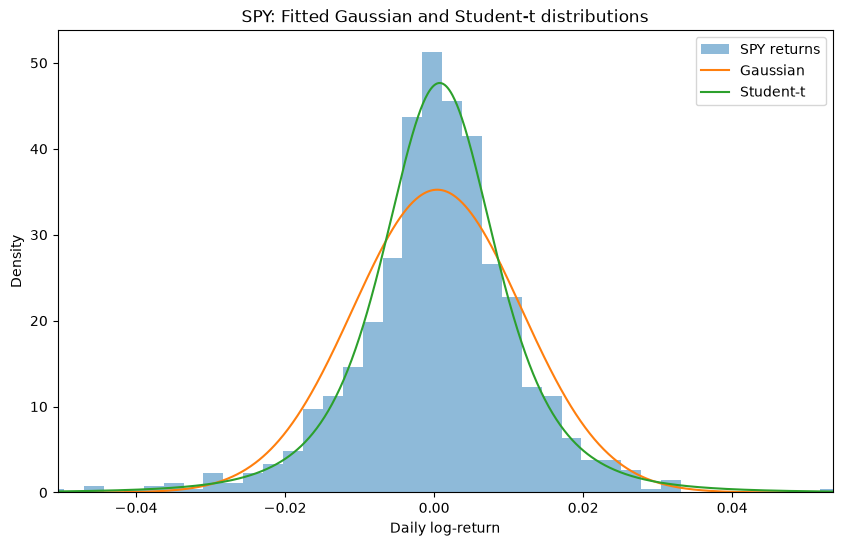

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma

# ============================================================
# 1. X-axis: empirical 0.1% to 99.9% range
# ============================================================

x_spy = np.linspace(
    np.quantile(spy_data, 0.001),
    np.quantile(spy_data, 0.999),
    1000
)


# ============================================================
# 2. Gaussian fitted density
# ============================================================

gaussian_density_spy = (
    1 / (sigma_spy * np.sqrt(2 * np.pi))
    * np.exp(
        -0.5 * ((x_spy - mu_spy) / sigma_spy) ** 2
    )
)


# ============================================================
# 3. Student-t fitted density
# ============================================================

student_t_density_spy = (
    1 / s_t_spy
    * gamma((nu_t_spy + 1) / 2)
    / (
        np.sqrt(nu_t_spy * np.pi)
        * gamma(nu_t_spy / 2)
    )
    * (
        1
        + ((x_spy - mu_t_spy) / s_t_spy) ** 2 / nu_t_spy
    ) ** (-(nu_t_spy + 1) / 2)
)


# ============================================================
# 4. Histogram + fitted distributions
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    spy_data,
    bins=60,
    density=True,
    alpha=0.5,
    label="SPY returns"
)

plt.plot(
    x_spy,
    gaussian_density_spy,
    label="Gaussian"
)

plt.plot(
    x_spy,
    student_t_density_spy,
    label="Student-t"
)

plt.xlim(
    np.quantile(spy_data, 0.001),
    np.quantile(spy_data, 0.999)
)

plt.xlabel("Daily log-return")
plt.ylabel("Density")
plt.title("SPY: Fitted Gaussian and Student-t distributions")
plt.legend()
plt.show()

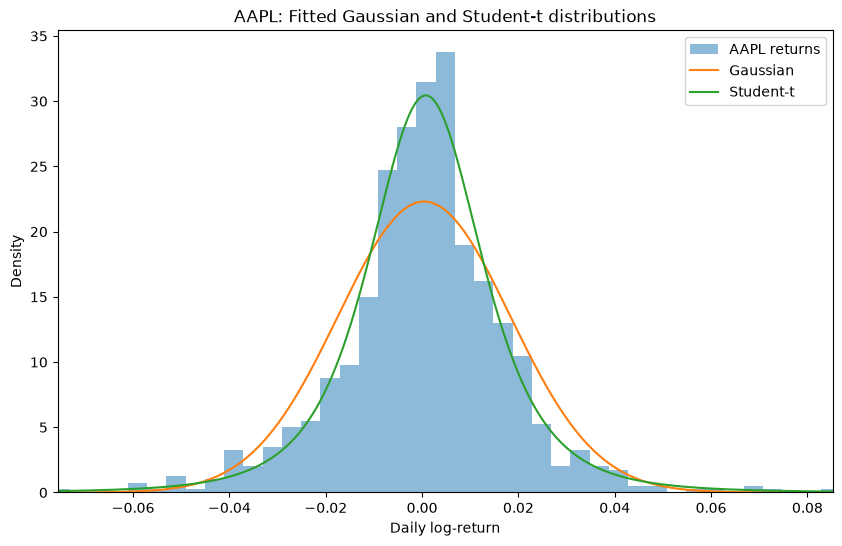

In [41]:
# ============================================================
# AAPL: fitted Gaussian and Student-t distributions
# ============================================================

# 1. X-axis: empirical 0.1% to 99.9% range
x_aapl = np.linspace(
    np.quantile(aapl_data, 0.001),
    np.quantile(aapl_data, 0.999),
    1000
)


# 2. Gaussian fitted density
gaussian_density_aapl = (
    1 / (sigma_aapl * np.sqrt(2 * np.pi))
    * np.exp(
        -0.5 * ((x_aapl - mu_aapl) / sigma_aapl) ** 2
    )
)


# 3. Student-t fitted density
student_t_density_aapl = (
    1 / s_t_aapl
    * gamma((nu_t_aapl + 1) / 2)
    / (
        np.sqrt(nu_t_aapl * np.pi)
        * gamma(nu_t_aapl / 2)
    )
    * (
        1
        + ((x_aapl - mu_t_aapl) / s_t_aapl) ** 2
        / nu_t_aapl
    ) ** (-(nu_t_aapl + 1) / 2)
)


# 4. Histogram + fitted distributions
plt.figure(figsize=(10, 6))

plt.hist(
    aapl_data,
    bins=60,
    density=True,
    alpha=0.5,
    label="AAPL returns"
)

plt.plot(
    x_aapl,
    gaussian_density_aapl,
    label="Gaussian"
)

plt.plot(
    x_aapl,
    student_t_density_aapl,
    label="Student-t"
)

plt.xlim(
    np.quantile(aapl_data, 0.001),
    np.quantile(aapl_data, 0.999)
)

plt.xlabel("Daily log-return")
plt.ylabel("Density")
plt.title("AAPL: Fitted Gaussian and Student-t distributions")
plt.legend()
plt.show()

In [42]:
# Select the Adjusted Close prices
spy_price = spy["Adj Close"].dropna()

# Calculate daily log-returns
spy_returns = np.log(
    spy_price / spy_price.shift(1)
).dropna()

# Convert to a 1D array for our calculations
spy_data = spy_returns.to_numpy().ravel()

print(spy_returns.head())
print("Number of returns:", len(spy_data))

Ticker           SPY
Date                
2022-01-04 -0.000335
2022-01-05 -0.019389
2022-01-06 -0.000940
2022-01-07 -0.003961
2022-01-10 -0.001245
Number of returns: 1002


In [43]:
q_spy_01 = np.quantile(spy_data, 0.01)
q_spy_99 = np.quantile(spy_data, 0.99)

print("SPY 1% quantile:", q_spy_01)
print("SPY 99% quantile:", q_spy_99)

SPY 1% quantile: -0.03251827286939317
SPY 99% quantile: 0.026045405193113887


In [44]:
# Gaussian MLE parameters for SPY
mu_spy = np.mean(spy_data)

sigma_spy = np.sqrt(
    np.mean((spy_data - mu_spy)**2)
)

print("mu =", mu_spy)
print("sigma =", sigma_spy)

mu = 0.00041068513367791833
sigma = 0.01132035361661872


In [45]:
from scipy.special import ndtr

p_gaussian_left = ndtr(
    (q_spy_01 - mu_spy) / sigma_spy
)

p_gaussian_right = 1 - ndtr(
    (q_spy_99 - mu_spy) / sigma_spy
)

print("Gaussian left-tail probability:", p_gaussian_left)
print("Gaussian right-tail probability:", p_gaussian_right)

Gaussian left-tail probability: 0.0018139337962568833
Gaussian right-tail probability: 0.011772288772711526


In [46]:
from scipy.special import betainc

def student_t_cdf(x, mu, s, nu):
    z = (x - mu) / s

    if z >= 0:
        return 1 - 0.5 * betainc(
            nu / 2,
            0.5,
            nu / (nu + z**2)
        )
    else:
        return 0.5 * betainc(
            nu / 2,
            0.5,
            nu / (nu + z**2)
        )


p_student_left = student_t_cdf(
    q_spy_01,
    mu_t_spy,
    s_t_spy,
    nu_t_spy
)

p_student_right = 1 - student_t_cdf(
    q_spy_99,
    mu_t_spy,
    s_t_spy,
    nu_t_spy
)

print("Student-t left-tail probability:", p_student_left)
print("Student-t right-tail probability:", p_student_right)

Student-t left-tail probability: 0.007767887849374451
Student-t right-tail probability: 0.0178437161537085
